In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Auto-detect project root (looks for "data" folder)
BASE_DIR = Path.cwd()
while not (BASE_DIR / "data").exists():
    if BASE_DIR == BASE_DIR.parent:  # safety check (reached filesystem root)
        raise FileNotFoundError(
            "Could not find 'data' directory in any parent folders."
        )
    BASE_DIR = BASE_DIR.parent

# Define paths
data_dir = BASE_DIR / "data" / "raw"
donations_path = data_dir / "donation_records.csv"
donors_path = data_dir / "donor_profiles.csv"

# Optional debug (remove later)
print("Project root:", BASE_DIR)
print("Data path:", data_dir)

# Load data
donations = pd.read_csv(donations_path)
donors = pd.read_csv(donors_path)

# Merge
df = donations.merge(donors, on="donor_id", how="left")

# Fix types
df["donation_date"] = pd.to_datetime(df["donation_date"])
df["donation_amount"] = pd.to_numeric(df["donation_amount"], errors="coerce")

df.head()

Project root: /Users/stann-omar.jones/Projects/github-repos/donor-retention-propensity-framework
Data path: /Users/stann-omar.jones/Projects/github-repos/donor-retention-propensity-framework/data/raw


,donation_id,donor_id,donation_date,donation_type,donation_amount,payment_method_x,campaign,name,age_group,gender,email,country,newsletter_opt_in,payment_method_y,referral_channel,sector
0,DON000001,55082a0b-1ced-4690-b27a-bef30498e823,2024-05-10,One-time,1.00,Paypal,Marine Mammal Defense Mission,Alexander Hill,30-49,Male,alexander.hill@example.com,Australia,False,Paypal,Social Media,Government
1,DON000002,d4896afd-2f85-4d4d-8c78-f535b4949eae,2025-03-22,One-time,118.24,Bank Transfer,Marine Mammal Defense Mission,Nancy Rhodes,50-65,Female,nancy.rhodes@example.com,UK,False,Bank Transfer,Website,Healthcare
2,DON000003,19272d49-6478-4e35-8516-a2242b702dc1,2024-01-29,Recurring,33.76,Bank Transfer,Rescue Orphaned Gorillas,Brandon Henderson,30-49,Male,brandon.henderson@example.com,France,False,Bank Transfer,Local event,Technology
3,DON000004,19272d49-6478-4e35-8516-a2242b702dc1,2024-11-02,Recurring,13.59,Bank Transfer,Habitat for Hope,Brandon Henderson,30-49,Male,brandon.henderson@example.com,France,False,Bank Transfer,Local event,Technology
4,DON000005,19272d49-6478-4e35-8516-a2242b702dc1,2024-11-07,Recurring,44.63,Bank Transfer,Rescue Orphaned Gorillas,Brandon Henderson,30-49,Male,brandon.henderson@example.com,France,False,Bank Transfer,Local event,Technology


In [2]:
donor_summary = (
    df.groupby("donor_id")
    .agg(
        donation_count=("donation_id", "count"),
        total_donated=("donation_amount", "sum"),
        avg_donation=("donation_amount", "mean"),
        first_donation=("donation_date", "min"),
        last_donation=("donation_date", "max"),
        recurring_donations=("donation_type", lambda x: (x == "Recurring").sum()),
    )
    .reset_index()
)

# Define reference date
reference_date = df["donation_date"].max()

# Add derived fields
donor_summary["is_repeat_donor"] = donor_summary["donation_count"] > 1

donor_summary["recency_days"] = (
    reference_date - donor_summary["last_donation"]
).dt.days

donor_summary.head()

,donor_id,donation_count,total_donated,avg_donation,first_donation,last_donation,recurring_donations,is_repeat_donor,recency_days
0,000c5955-4586-43c1-8ad7-a9517fd761ac,1,37.92,37.92,2025-03-31,2025-03-31,0,False,80
1,00135b8c-edd1-4db7-b3d5-b62a68a5cdd4,1,108.33,108.33,2024-04-30,2024-04-30,0,False,415
2,00150fbc-8415-44f7-97c9-14e26183417f,1,41.80,41.80,2025-03-27,2025-03-27,0,False,84
3,0015bc3b-1d80-444b-a834-54ec043a366d,1,77.99,77.99,2023-07-29,2023-07-29,0,False,691
4,001dd405-0928-472b-8d3b-2267e01ce5f2,1,60.34,60.34,2024-02-10,2024-02-10,0,False,495


In [3]:
total_donors = donor_summary.shape[0]
total_revenue = df["donation_amount"].sum()
repeat_rate = donor_summary["is_repeat_donor"].mean()
recurring_share = (
    df[df["donation_type"] == "Recurring"]["donation_amount"].sum() / total_revenue
)

summary = {
    "Total donors": total_donors,
    "Total revenue": f"${total_revenue:,.2f}",
    "Repeat donor rate": f"{repeat_rate:.2%}",
    "Recurring revenue share": f"{recurring_share:.2%}",
}

for k, v in summary.items():
    print(f"{k}: {v}")

Total donors: 8800
Total revenue: $784,080.38
Repeat donor rate: 20.51%
Recurring revenue share: 42.22%


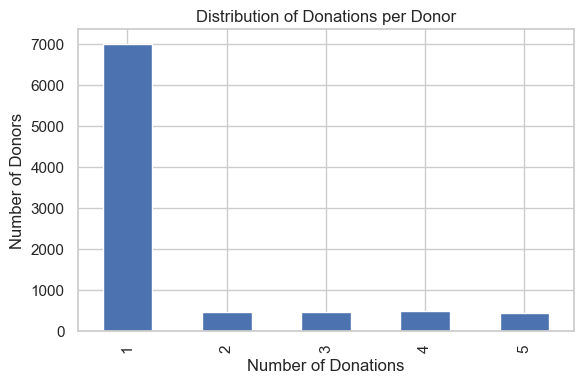

In [4]:
plt.figure(figsize=(6, 4))
donor_summary["donation_count"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Donations per Donor")
plt.xlabel("Number of Donations")
plt.ylabel("Number of Donors")
plt.tight_layout()

output_dir = BASE_DIR / "outputs" / "charts"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "donations_per_donor.png")

In [5]:
recurring_stats = df.groupby("donation_type").agg(
    total_revenue=("donation_amount", "sum"),
    avg_donation=("donation_amount", "mean"),
    count=("donation_id", "count"),
)

recurring_stats

,total_revenue,avg_donation,count
donation_type,,,
One-time,453039.42,64.766179,6995
Recurring,331040.96,52.562871,6298


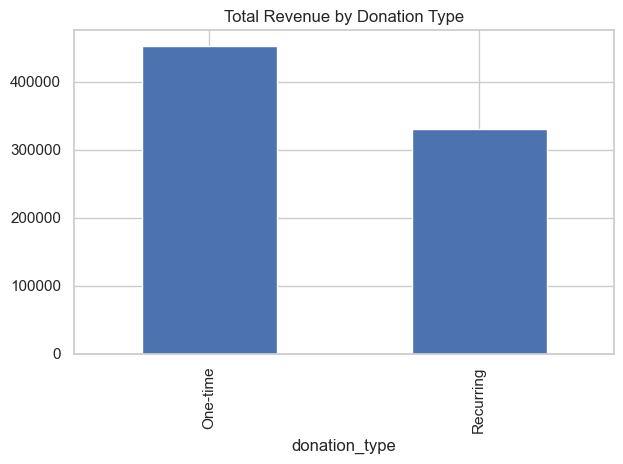

In [6]:
recurring_stats["total_revenue"].plot(kind="bar")
plt.title("Total Revenue by Donation Type")
plt.tight_layout()

output_dir = BASE_DIR / "outputs" / "charts"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "revenue_by_type.png")

In [7]:
donor_summary["freq_score"] = donor_summary["donation_count"]
donor_summary["recency_score"] = -donor_summary["recency_days"]
donor_summary["value_score"] = donor_summary["total_donated"]

# Normalize
for col in ["freq_score", "recency_score", "value_score"]:
    denom = donor_summary[col].max() - donor_summary[col].min()
    if denom != 0:
        donor_summary[col] = (donor_summary[col] - donor_summary[col].min()) / denom
    else:
        donor_summary[col] = 0

In [8]:
donor_summary["propensity_score"] = (
    0.5 * donor_summary["freq_score"]
    + 0.3 * donor_summary["recency_score"]
    + 0.2 * donor_summary["value_score"]
)

In [9]:
donor_summary["propensity_segment"] = pd.qcut(
    donor_summary["propensity_score"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

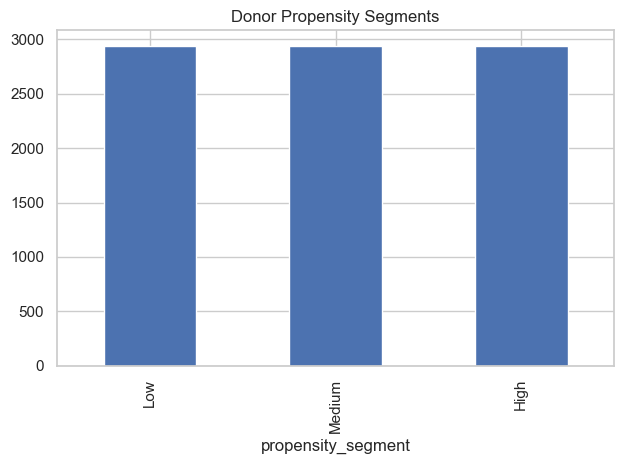

In [10]:
donor_summary["propensity_segment"].value_counts().plot(kind="bar")
plt.title("Donor Propensity Segments")
plt.tight_layout()

plt.savefig("../outputs/charts/propensity_segments.png")
plt.show()

In [11]:
donor_summary.head()

,donor_id,donation_count,total_donated,avg_donation,first_donation,last_donation,recurring_donations,is_repeat_donor,recency_days,freq_score,recency_score,value_score,propensity_score,propensity_segment
0,000c5955-4586-43c1-8ad7-a9517fd761ac,1,37.92,37.92,2025-03-31,2025-03-31,0,False,80,0.0,0.890411,0.085829,0.284289,High
1,00135b8c-edd1-4db7-b3d5-b62a68a5cdd4,1,108.33,108.33,2024-04-30,2024-04-30,0,False,415,0.0,0.431507,0.249512,0.179354,Medium
2,00150fbc-8415-44f7-97c9-14e26183417f,1,41.80,41.80,2025-03-27,2025-03-27,0,False,84,0.0,0.884932,0.094848,0.284449,High
3,0015bc3b-1d80-444b-a834-54ec043a366d,1,77.99,77.99,2023-07-29,2023-07-29,0,False,691,0.0,0.053425,0.178980,0.051823,Low
4,001dd405-0928-472b-8d3b-2267e01ce5f2,1,60.34,60.34,2024-02-10,2024-02-10,0,False,495,0.0,0.321918,0.137949,0.124165,Low


In [12]:
cutoff_date = df["donation_date"].quantile(0.8)

train_df = df[df["donation_date"] <= cutoff_date]
future_df = df[df["donation_date"] > cutoff_date]

In [13]:
donor_summary_train = (
    train_df.groupby("donor_id")
    .agg(
        donation_count=("donation_id", "count"),
        total_donated=("donation_amount", "sum"),
        last_donation=("donation_date", "max"),
    )
    .reset_index()
)

# Feature engineering
donor_summary_train["recency_days"] = (
    cutoff_date - donor_summary_train["last_donation"]
).dt.days

donor_summary_train["avg_donation"] = (
    donor_summary_train["total_donated"] / donor_summary_train["donation_count"]
)

In [14]:
future_donors = future_df["donor_id"].unique()

donor_summary_train["donated_again"] = (
    donor_summary_train["donor_id"].isin(future_donors)
).astype(int)

In [15]:
features = ["donation_count", "recency_days", "total_donated", "avg_donation"]

X = donor_summary_train[features]
y = donor_summary_train["donated_again"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"Model AUC: {auc:.3f}")

Model AUC: 0.820


In [19]:
donor_summary_train["ml_propensity_score"] = model.predict_proba(X)[:, 1]

donor_summary_train["ml_segment"] = pd.qcut(
    donor_summary_train["ml_propensity_score"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

In [20]:
pd.Series(model.coef_[0], index=features).sort_values(ascending=False)

donation_count    0.546641
total_donated     0.004090
recency_days     -0.001143
avg_donation     -0.016584
dtype: float64

In [21]:
donor_summary_train.groupby("ml_segment")["donated_again"].mean()

/var/folders/7t/nscydqzn0_zd1gy0r57jw6_c0000gp/T/ipykernel_53821/4147450652.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_summary_train.groupby("ml_segment")["donated_again"].mean()


ml_segment
Low       0.027676
Medium    0.037866
High      0.307285
Name: donated_again, dtype: float64

In [22]:
donor_summary_train.groupby("ml_segment").size()

/var/folders/7t/nscydqzn0_zd1gy0r57jw6_c0000gp/T/ipykernel_53821/3092281101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_summary_train.groupby("ml_segment").size()


ml_segment
Low       2457
Medium    2456
High      2457
dtype: int64

In [23]:
donor_summary_train.head()

,donor_id,donation_count,total_donated,last_donation,recency_days,avg_donation,donated_again,ml_propensity_score,ml_segment
0,00135b8c-edd1-4db7-b3d5-b62a68a5cdd4,1,108.33,2024-04-30,270,108.33,0,0.039153,Low
1,0015bc3b-1d80-444b-a834-54ec043a366d,1,77.99,2023-07-29,546,77.99,0,0.041617,Low
2,001dd405-0928-472b-8d3b-2267e01ce5f2,1,60.34,2024-02-10,350,60.34,0,0.063437,Medium
3,00239d3e-5114-410f-8671-cb5491cde942,1,59.89,2024-02-13,347,59.89,0,0.063977,Medium
4,002cfdde-07e4-4105-b158-038b158967be,1,106.16,2024-05-15,255,106.16,0,0.040853,Low


In [24]:
# Ensure output directory exists — anchored to project root, not notebook cwd
output_dir = BASE_DIR / "outputs"
output_dir.mkdir(exist_ok=True)

# Save merged / cleaned dataset
df.to_csv(output_dir / "donations_clean.csv", index=False)

print(f"Saved to {output_dir / 'donations_clean.csv'}")

Saved to /Users/stann-omar.jones/Projects/github-repos/donor-retention-propensity-framework/outputs/donations_clean.csv
